# Day 2 — Preprocessing and Logistic Regression baseline

This notebook first builds the **preprocessing pipeline** for NSL-KDD, then trains a **Logistic Regression** baseline.

We still **do not** train Random Forest or XGBoost, and we **do not** use SMOTE or hyperparameter tuning.

## 1. Why this preprocessing design

### 1. What data leakage is

**Data leakage** is when the model (or its preprocessing) sees information it would not have in a real deployment. Examples: using `label` as a feature, mixing train and test, or computing scaler means from the test set. Leakage makes scores look better than they will be on new traffic.

### 2. Why preprocessing must be fitted only on training data

`StandardScaler` learns a mean and standard deviation. `OneHotEncoder` learns which category values exist. Those statistics must come from **KDDTrain+ only**. If we fit on test (or train+test), test information leaks into the transformation, and evaluation is no longer honest.

### 3. Why we use ColumnTransformer

The 41 features are mixed: 3 text columns and 38 numeric columns. They need **different** treatments. `ColumnTransformer` applies OneHotEncoder to the categorical list and StandardScaler to the numerical list, then concatenates the results. We do not scale strings or one-hot encode byte counts.

### 4. Why categorical features need OneHotEncoder

`protocol_type`, `service`, and `flag` are strings (`tcp`, `http`, `SF`, …). Logistic Regression (later) needs numbers. One-hot encoding creates 0/1 columns for each category so the model does not treat category names as ordered magnitudes.

### 5. Why OneHotEncoder must use `handle_unknown="ignore"`

KDDTest+ contains **service (and possibly other) values that never appear in training**. The default encoder would **error** on unknown categories. `handle_unknown="ignore"` encodes unknown values as all zeros in those one-hot columns, so transform still succeeds and the number of output columns stays the same as training.

### 6. Why numerical features are scaled for Logistic Regression

Logistic Regression uses a weighted sum of features. `src_bytes` can be huge while rate features stay in `[0, 1]`. Unscaled large columns can dominate. `StandardScaler` puts numeric columns on a comparable scale (mean 0, variance 1). We fit those means/stds on **train only**. (Tree models later generally do not need this; we still include it in this shared preprocessor for the linear baseline.)

### 7. Why preprocessing should be inside an sklearn Pipeline

A `Pipeline` bundles steps so we cannot accidentally fit the scaler on test, forget to encode, or apply steps in the wrong order. Later we will add a classifier **after** this same preprocess step. For today the pipeline contains **only** preprocessing.

### 8. Why the test set must remain untouched until evaluation

KDDTest+ is the held-out estimate of real-world performance. We may **transform** it with a pipeline already fitted on train, but we must not **fit** anything on it, not merge it with train, and not tune using its labels until we are ready to report metrics (a later step).

## 2. Imports

Only libraries needed to load tables and build the preprocessor. No classifiers.

In [14]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

## 3. Load NSL-KDD and recreate Day 1 X / y

Same 43 column names, same five-class map, same 41 predictive features as `01_eda.ipynb`.
Train and test stay in **separate** DataFrames.

In [15]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty",
]

attack_category_map = {
    "normal": "Normal",
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "udpstorm": "DoS",
    "processtable": "DoS",
    "mailbomb": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}

train_path = "../data/raw/KDDTrain+.txt"
test_path = "../data/raw/KDDTest+.txt"

train_df = pd.read_csv(train_path, header=None, names=COLUMNS)
test_df = pd.read_csv(test_path, header=None, names=COLUMNS)

train_df["attack_category"] = train_df["label"].map(attack_category_map)
test_df["attack_category"] = test_df["label"].map(attack_category_map)

feature_columns = [col for col in COLUMNS if col not in ["label", "difficulty"]]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df["attack_category"]
y_test = test_df["attack_category"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Number of predictive features:", len(feature_columns))

X_train shape: (125973, 41)
X_test shape: (22544, 41)
y_train shape: (125973,)
y_test shape: (22544,)
Number of predictive features: 41


## 4. Categorical vs numerical feature lists

These lists tell `ColumnTransformer` which transformer to apply to which columns.

In [16]:
categorical_features = ["protocol_type", "service", "flag"]
numerical_features = [col for col in feature_columns if col not in categorical_features]

print("Categorical features (", len(categorical_features), "):", sep="")
print(categorical_features)
print()
print("Numerical features (", len(numerical_features), "):", sep="")
print(numerical_features)

Categorical features (3):
['protocol_type', 'service', 'flag']

Numerical features (38):
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 5. Build the preprocessor (not fitted yet)

- `OneHotEncoder(handle_unknown="ignore")` for the 3 text columns
- `StandardScaler()` for the 38 numeric columns
- `ColumnTransformer` routes each group to the right transformer
- `preprocessing_pipeline` wraps that as a single sklearn object

No classifier is added.

In [17]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features),
    ]
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
    ]
)

preprocessing_pipeline

,steps,"[('preprocess', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Fit on train only, then transform train and test

`fit` learns category lists and numeric mean/std from **X_train only**.
`transform` then applies those same learned rules to train and to test.
We never call `fit` on `X_test`.

In [18]:
preprocessing_pipeline.fit(X_train)

X_train_transformed = preprocessing_pipeline.transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_test shape:", X_test_transformed.shape)
print()

same_n_columns = X_train_transformed.shape[1] == X_test_transformed.shape[1]
print("Train and test have the same number of transformed columns:", same_n_columns)

if not same_n_columns:
    raise ValueError("Transformed train and test column counts differ.")

Original X_train shape: (125973, 41)
Transformed X_train shape: (125973, 122)
Transformed X_test shape: (22544, 122)

Train and test have the same number of transformed columns: True


## 7. Why we transform X_test with the already-fitted pipeline

After `fit(X_train)`, the pipeline stores:

- which one-hot columns exist (from training categories only)
- the mean and standard deviation of each numeric column (from training only)

`transform(X_test)` **reuses** those stored values. That is what a real detector would do: apply the rules learned from past traffic to new traffic.

If we fitted a **new** encoder/scaler on `X_test`:

- test means would leak into the transformation
- one-hot columns could differ (test-only `service` values), so train and test would not share the same feature space
- later model scores would be optimistic and not comparable

Unknown test categories are handled by `handle_unknown="ignore"` (all-zero one-hot), so the **column count stays aligned** with training.

The transformed matrices are **wider** than 41 columns because each categorical value becomes its own 0/1 column, then the 38 scaled numeric columns are appended.

The next section adds Logistic Regression **after** this same preprocessor, inside a new pipeline. The test set is still not used for fitting.

## 8. Why Logistic Regression as the first baseline

### 1. Why this model is useful here

Logistic Regression is a **simple, linear** classifier. It is fast to reason about, uses the same sklearn `Pipeline` we already designed, and gives a **floor** for later models (Random Forest, XGBoost). If a more complex model cannot beat this baseline, something is wrong with the setup—not just “we need a bigger model.”

### 2. What multi-class classification means for us

Each connection belongs to **exactly one** of five labels: **Normal, DoS, Probe, R2L, U2R**. The model outputs one of those five for every test row. That is multi-class classification (not binary “attack vs normal”).

### 3. Why Logistic Regression benefits from StandardScaler

It scores a class with a **weighted sum** of features. Unscaled columns on huge scales (bytes) can drown columns on `[0, 1]` (rates). Our preprocessor already applies `StandardScaler` to the 38 numeric features, so this baseline is using that design.

### 4. Why we train only on `X_train` and `y_train`

`fit` must see only KDDTrain+. Fitting on test, or on train+test, is leakage: the model would memorize evaluation traffic and the test score would not be a fair estimate of new data.

### 5. Why we evaluate on `X_test` only after training

KDDTest+ stays **held out** until `predict`. We then compare predictions to `y_test`. That mimics deploying a detector on new traffic it was not trained on (including some attack names never seen in training).

### 6. Why accuracy is not enough

Accuracy is the fraction of rows that are correct. Test data is still dominated by Normal and DoS. A model can look “good” while missing **R2L** and **U2R**. We also report **macro** precision, recall, and F1 (unweighted average over the five classes) and a **per-class** report plus a **confusion matrix**.

## 9. Logistic Regression pipeline

We reuse the existing `preprocessor` (`ColumnTransformer`: one-hot + scaling). `logistic_pipeline` adds `LogisticRegression` as the next step.

- `max_iter=1000` — more optimizer steps so it is likelier to converge on this dataset  
- `class_weight="balanced"` — up-weight rare classes (R2L, U2R) during training; this is **not** SMOTE  
- `random_state=42` — reproducible solver behavior where it applies  

`fit` uses **only** `X_train` and `y_train`. Fitting may take a couple of minutes.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train, y_train)
y_pred = logistic_pipeline.predict(X_test)

print("logistic_pipeline fitted on X_train / y_train.")
print("Predictions generated on X_test only.")

logistic_pipeline fitted on X_train / y_train.
Predictions generated on X_test only.


## 10. Test-set metrics

All scores below compare `y_pred` to `y_test`. Macro metrics treat the five classes equally, so a failure on U2R hurts as much as a failure on Normal.

In [20]:
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)
macro_recall = recall_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)
macro_f1 = f1_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

Accuracy:        0.7893
Macro precision: 0.6871
Macro recall:    0.6727
Macro F1:        0.6024


## 11. Classification report and confusion matrix

The report shows precision, recall, F1, and support (how many test rows) **per class**.

The heatmap is the confusion matrix: **rows = true class**, **columns = predicted class**. The diagonal is correct predictions.

Classification report (test set):
              precision    recall  f1-score   support

      Normal     0.7320    0.9140    0.8129      9711
         DoS     0.9190    0.8304    0.8725      7460
       Probe     0.8223    0.8451    0.8336      2421
         R2L     0.8826    0.2215    0.3541      2885
         U2R     0.0796    0.5522    0.1391        67

    accuracy                         0.7893     22544
   macro avg     0.6871    0.6727    0.6024     22544
weighted avg     0.8209    0.7893    0.7741     22544

Confusion matrix (rows = true, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,8876,416,348,34,37
DoS,1190,6195,73,0,2
Probe,205,127,2046,37,6
R2L,1839,3,21,639,383
U2R,16,0,0,14,37


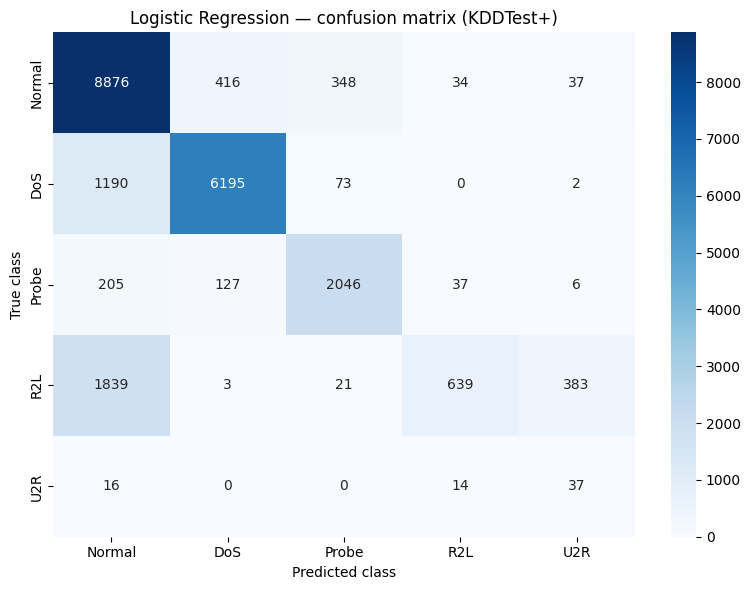

In [21]:
print("Classification report (test set):")
print(
    classification_report(
        y_test,
        y_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=category_order)
cm_df = pd.DataFrame(cm, index=category_order, columns=category_order)
print("Confusion matrix (rows = true, columns = predicted):")
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)
plt.title("Logistic Regression — confusion matrix (KDDTest+)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Baseline Interpretation

The figures below are taken from the test-set output already produced. They describe **what the model did**. They do not, by themselves, explain **why** those errors occurred.

**Overall scores (observed)**

- **Accuracy = 0.7893** — 78.93% of the 22,544 test rows were labeled correctly.
- **Macro F1 = 0.6024** — unweighted mean of the five per-class F1 scores.

**Stronger classes (observed in the classification report)**

- **Normal:** precision 0.7320, recall 0.9140, F1 0.8129 (support 9711)
- **DoS:** precision 0.9190, recall 0.8304, F1 0.8725 (support 7460)
- **Probe:** precision 0.8223, recall 0.8451, F1 0.8336 (support 2421)

These three have the highest F1 scores on KDDTest+.

**Weaker classes (observed)**

- **R2L recall = 0.2215** (precision 0.8826, F1 0.3541, support 2885). Most true R2L rows were not predicted as R2L.
- **U2R precision = 0.0796** with **U2R recall = 0.5522** (F1 0.1391, support 67). More than half of true U2R rows were found, but most rows predicted as U2R were not U2R.

**R2L → U2R (observed in the confusion matrix)**

Rows = true class; columns = predicted class (Normal, DoS, Probe, R2L, U2R).

True **R2L** counts: 1839 Normal, 3 DoS, 21 Probe, 639 R2L, **383 U2R**.

The U2R **prediction** column is 37 + 2 + 6 + 383 + 37 = **465**. Only **37** of those are true U2R; **383** are true R2L. That matches U2R precision 0.0796 (37 / 465). This is a count from the matrix, not a claim about why R2L and U2R were mixed up.

**Accuracy vs macro F1 (what the metrics do)**

Accuracy treats every **row** equally. Most test rows are Normal or DoS, and those classes scored well, so accuracy can be 0.7893 even though R2L recall is 0.2215 and U2R F1 is 0.1391.

Macro F1 treats every **class** equally. The low R2L and U2R F1 scores pull the average down to 0.6024. The gap between 0.7893 and 0.6024 is therefore the effect of **class imbalance on the choice of metric**: a row-weighted score can look much better than a class-weighted score when common classes dominate.

**Baseline role**

This Logistic Regression result is our **baseline**. Random Forest and XGBoost will be compared against these same test numbers, especially macro F1 and the R2L / U2R scores, not accuracy alone.

## Random Forest Model

Logistic Regression is the **fixed baseline**. This section adds a **Random Forest** using the same preprocessor, the same `X_train` / `y_train` / `X_test` / `y_test`, and the same metrics so the comparison is controlled.

### 1. Why Random Forest is useful for network traffic

NSL-KDD mixes counts, rates, and 0/1 flags. Attack types need not be linearly separable. A Random Forest can split on different features in different trees (for example a byte threshold in one tree and a rate threshold in another), which is a common fit for tabular traffic records.

### 2. How it combines trees (high level)

A Random Forest trains **many decision trees** on different random subsets of rows and features. At prediction time, the trees **vote**. The class with the most votes is the output. The goal is a more stable rule than any single tree.

### 3. Nonlinear relationships vs Logistic Regression

Logistic Regression scores each class with a **weighted sum** of features (a linear decision surface in the transformed space). A tree can use **if/then splits** and combinations of splits, so interactions such as “high `src_bytes` **and** a certain `flag`” do not have to be written as extra columns. Whether that helps **this** test set is an empirical question—we check the metrics below rather than assume it.

### 4. Why trees do not fundamentally need scaling

A split such as `src_bytes > 1000` does not change if we divide every `src_bytes` value by a constant. Orderings and thresholds are invariant to that kind of rescaling, so `StandardScaler` is not required for the forest itself.

### 5. Why we keep the same preprocessor anyway

This first comparison is **controlled**: the only intended change is the classifier. If we dropped scaling or changed encoding only for the forest, we would not know whether a metric shift came from the model or from a different feature pipeline. We reuse the existing `preprocessor` (OneHotEncoder + StandardScaler).

### 6. Why the same data and metrics are required

Fair comparison means:

- the same training rows (`X_train`, `y_train`)
- the same held-out test rows (`X_test`, `y_test`)
- the same scores: accuracy, macro precision / recall / F1, per-class report, confusion matrix

We do not retune, do not use SMOTE, and do not train XGBoost here. We do **not** call Random Forest better unless the numbers show it.

## Random Forest pipeline

Reuse `preprocessor`. Fit only on training data. Predict only on the test set. Store Random Forest outputs in `rf_*` variables so Logistic Regression’s `y_pred`, `accuracy`, and macro scores stay unchanged.

In [22]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

random_forest_pipeline.fit(X_train, y_train)
rf_pred = random_forest_pipeline.predict(X_test)

print("random_forest_pipeline fitted on X_train / y_train.")
print("Predictions generated on X_test only.")
print("Logistic Regression y_pred was not overwritten.")

random_forest_pipeline fitted on X_train / y_train.
Predictions generated on X_test only.
Logistic Regression y_pred was not overwritten.


## Random Forest test-set metrics

Same metric functions and `category_order` as the Logistic Regression evaluation.

Accuracy:        0.7388
Macro precision: 0.7502
Macro recall:    0.4744
Macro F1:        0.4773

Classification report (Random Forest, test set):
              precision    recall  f1-score   support

      Normal     0.6375    0.9738    0.7706      9711
         DoS     0.9614    0.7704    0.8553      7460
       Probe     0.8399    0.5936    0.6955      2421
         R2L     0.8125    0.0045    0.0090      2885
         U2R     0.5000    0.0299    0.0563        67

    accuracy                         0.7388     22544
   macro avg     0.7502    0.4744    0.4773     22544
weighted avg     0.7884    0.7388    0.6910     22544

Confusion matrix (rows = true, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,9457,67,186,0,1
DoS,1628,5747,85,0,0
Probe,820,164,1437,0,0
R2L,2868,0,3,13,1
U2R,62,0,0,3,2


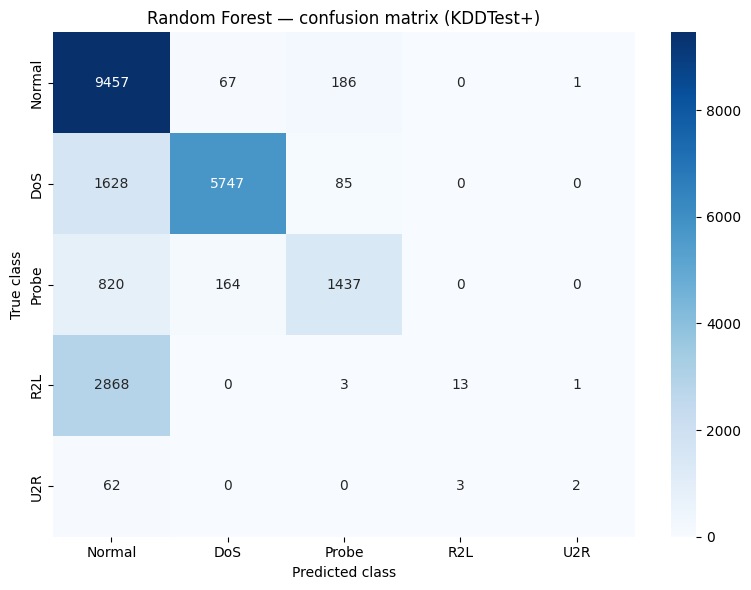

In [23]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_macro_precision = precision_score(
    y_test, rf_pred, average="macro", labels=category_order, zero_division=0
)
rf_macro_recall = recall_score(
    y_test, rf_pred, average="macro", labels=category_order, zero_division=0
)
rf_macro_f1 = f1_score(
    y_test, rf_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Accuracy:        {rf_accuracy:.4f}")
print(f"Macro precision: {rf_macro_precision:.4f}")
print(f"Macro recall:    {rf_macro_recall:.4f}")
print(f"Macro F1:        {rf_macro_f1:.4f}")
print()
print("Classification report (Random Forest, test set):")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

rf_cm = confusion_matrix(y_test, rf_pred, labels=category_order)
rf_cm_df = pd.DataFrame(rf_cm, index=category_order, columns=category_order)
print("Confusion matrix (rows = true, columns = predicted):")
display(rf_cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)
plt.title("Random Forest — confusion matrix (KDDTest+)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Comparison table

Logistic Regression scores come from the variables already computed (`accuracy`, `macro_precision`, `macro_recall`, `macro_f1`). Random Forest scores are `rf_*`. Neither model is retrained here.

In [24]:
comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Accuracy": [accuracy, rf_accuracy],
        "Macro Precision": [macro_precision, rf_macro_precision],
        "Macro Recall": [macro_recall, rf_macro_recall],
        "Macro F1": [macro_f1, rf_macro_f1],
    }
)

print("Test-set comparison (KDDTest+):")
display(comparison_df.round(4))

Test-set comparison (KDDTest+):


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.7893,0.6871,0.6727,0.6024
1,Random Forest,0.7388,0.7502,0.4744,0.4773


## Random Forest vs Logistic Regression

These figures are the observed test scores already printed. Logistic Regression remains the **baseline**.

**Headline scores**

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.7893 | 0.6871 | 0.6727 | 0.6024 |
| Random Forest | 0.7388 | 0.7502 | 0.4744 | 0.4773 |

**Who wins this comparison.** Logistic Regression has the higher **Macro F1** (0.6024 vs 0.4773) and therefore **wins** the current comparison. It also has higher accuracy (0.7893 vs 0.7388) and higher macro recall (0.6727 vs 0.4744).

**Precision vs recall.** Random Forest has **higher macro precision** (0.7502 vs 0.6871) but **substantially lower macro recall** (0.4744 vs 0.6727). That is a precision/recall tradeoff: when it does predict a minority class it is more often correct, but it predicts those classes far too rarely. The higher minority-class precision **does not compensate** for the extremely low recall, which is why Macro F1 falls.

**R2L (observed).** Random Forest R2L recall is **0.0045**, versus **0.2215** for Logistic Regression. The forest correctly classified **13 of 2885** R2L test samples. **2868** true R2L samples were classified as **Normal**.

**U2R (observed).** Random Forest U2R recall is **0.0299**. It correctly classified **2 of 67** U2R samples.

**What this does *not* show.** These results are for **this specific configuration** (`n_estimators=200`, `class_weight="balanced"`, `random_state=42`, same preprocessor). They do **not** show that Random Forest inherently cannot handle NSL-KDD. Other settings are unevaluated here.

**Class imbalance (hypothesis, not a proven sole cause).** Day 1 EDA showed severe imbalance (R2L and especially U2R are rare in training). That imbalance is a **likely contributing factor** to the very low R2L/U2R recall under this forest, because a model can score many rows correctly by favoring common classes. It is **not** established here as the only cause, and we did not run an experiment that isolates imbalance from other differences.

**Next.** XGBoost will be evaluated next under the **same** experimental conditions: same preprocessor design, same train/test split, and the same metrics, with Logistic Regression kept as the fixed baseline.

## Random Forest Preprocessing Check

The scaled Random Forest above is **unchanged**. This extra experiment asks only: does `StandardScaler` **materially** change that forest’s test scores?

We build a **separate** preprocessor:

- categorical: `OneHotEncoder(handle_unknown="ignore")` (same as before)
- numerical: **`passthrough`** (raw numbers; no scaling)

The classifier settings stay the same (`n_estimators=200`, `random_state=42`, `n_jobs=-1`, `class_weight="balanced"`). Train and test data are the same. Results are stored in `rf_noscale_*` so the original Random Forest variables are not overwritten.

In [25]:
random_forest_preprocessor_no_scaling = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
    ]
)

random_forest_no_scaling_pipeline = Pipeline(
    [
        ("preprocessor", random_forest_preprocessor_no_scaling),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

random_forest_no_scaling_pipeline.fit(X_train, y_train)
rf_noscale_pred = random_forest_no_scaling_pipeline.predict(X_test)

print("random_forest_no_scaling_pipeline fitted on X_train / y_train.")
print("Original random_forest_pipeline results were not overwritten.")

random_forest_no_scaling_pipeline fitted on X_train / y_train.
Original random_forest_pipeline results were not overwritten.


## Random Forest without scaling — test metrics

Same metrics and `category_order` as the other models.

Accuracy:        0.7388
Macro precision: 0.6502
Macro recall:    0.4685
Macro F1:        0.4661

Classification report (Random Forest, no scaling, test set):
              precision    recall  f1-score   support

      Normal     0.6375    0.9738    0.7706      9711
         DoS     0.9614    0.7708    0.8556      7460
       Probe     0.8398    0.5931    0.6952      2421
         R2L     0.8125    0.0045    0.0090      2885
         U2R     0.0000    0.0000    0.0000        67

    accuracy                         0.7388     22544
   macro avg     0.6502    0.4685    0.4661     22544
weighted avg     0.7869    0.7388    0.6909     22544

Confusion matrix (rows = true, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,9457,67,186,0,1
DoS,1625,5750,85,0,0
Probe,821,164,1436,0,0
R2L,2868,0,3,13,1
U2R,64,0,0,3,0


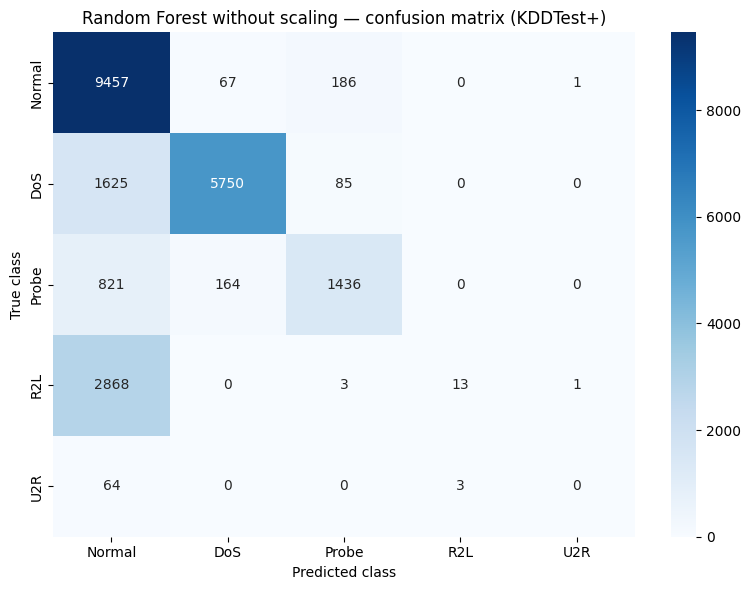

In [26]:
rf_noscale_accuracy = accuracy_score(y_test, rf_noscale_pred)
rf_noscale_macro_precision = precision_score(
    y_test, rf_noscale_pred, average="macro", labels=category_order, zero_division=0
)
rf_noscale_macro_recall = recall_score(
    y_test, rf_noscale_pred, average="macro", labels=category_order, zero_division=0
)
rf_noscale_macro_f1 = f1_score(
    y_test, rf_noscale_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Accuracy:        {rf_noscale_accuracy:.4f}")
print(f"Macro precision: {rf_noscale_macro_precision:.4f}")
print(f"Macro recall:    {rf_noscale_macro_recall:.4f}")
print(f"Macro F1:        {rf_noscale_macro_f1:.4f}")
print()
print("Classification report (Random Forest, no scaling, test set):")
print(
    classification_report(
        y_test,
        rf_noscale_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

rf_noscale_cm = confusion_matrix(y_test, rf_noscale_pred, labels=category_order)
rf_noscale_cm_df = pd.DataFrame(
    rf_noscale_cm, index=category_order, columns=category_order
)
print("Confusion matrix (rows = true, columns = predicted):")
display(rf_noscale_cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_noscale_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)
plt.title("Random Forest without scaling — confusion matrix (KDDTest+)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Scaling vs no scaling (Random Forest only)

The first row uses the existing scaled Random Forest variables (`rf_accuracy`, …). The second row uses this experiment (`rf_noscale_*`). Logistic Regression is not included here.

In [27]:
rf_scaling_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Random Forest with scaling",
            "Random Forest without scaling",
        ],
        "Accuracy": [rf_accuracy, rf_noscale_accuracy],
        "Macro Precision": [rf_macro_precision, rf_noscale_macro_precision],
        "Macro Recall": [rf_macro_recall, rf_noscale_macro_recall],
        "Macro F1": [rf_macro_f1, rf_noscale_macro_f1],
    }
)

print("Random Forest preprocessing check (KDDTest+):")
display(rf_scaling_comparison_df.round(4))

Random Forest preprocessing check (KDDTest+):


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest with scaling,0.7388,0.7502,0.4744,0.4773
1,Random Forest without scaling,0.7388,0.6502,0.4685,0.4661


## Random Forest Preprocessing Check — interpretation

Observed test scores for this check:

| Configuration | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| Random Forest **with** scaling | 0.7388 | 0.7502 | 0.4744 | 0.4773 |
| Random Forest **without** scaling | 0.7388 | 0.6502 | 0.4685 | 0.4661 |

**Did removing scaling materially change performance?**  
**Accuracy did not change** (both **0.7388**). **R2L recall stayed 0.0045** (still **13 of 2885** correct; still **2868** predicted Normal). Normal / DoS / Probe counts in the two confusion matrices differ by only a few rows.

Macro F1 moved slightly (**0.4773 → 0.4661**) and macro precision more (**0.7502 → 0.6502**). Those macro shifts are driven mainly by **U2R**: with scaling, **2 of 67** U2R rows were correct (recall 0.0299, precision 0.5000); without scaling, **0 of 67** were correct. Because macro metrics average the five classes equally, two U2R rows can move macro precision/F1 even when overall accuracy is unchanged.

So: dropping `StandardScaler` did **not** fix the forest’s failure on rare classes, and it did **not** change accuracy. It is **not** supported to say that scaling caused the original poor Random Forest result.

**Why trees generally do not require numerical scaling.**  
A tree split is a threshold on one feature (for example `src_bytes > 1000`). Changing units or subtracting a mean does not change the **order** of values on that feature, so the same split logic is available with or without `StandardScaler`. That is why a large accuracy change was not expected. Small count differences (as seen for U2R) can still appear because scaled vs raw values can lead to slightly different split choices; that is an observation of small matrix differences, not proof of a mechanism.

**What this experiment does not show.**  
It does not show that Random Forest cannot work on NSL-KDD, only that **this configuration**, with or without scaling, performed poorly on R2L and U2R. Logistic Regression remains the baseline. XGBoost is not trained here.

## XGBoost Model

Logistic Regression and Random Forest stay as already run. This section adds **XGBoost** under the same train/test split and the **same** `preprocessor` used for Logistic Regression (OneHotEncoder + StandardScaler).

1. **XGBoost is a gradient-boosted tree ensemble.** It fits many decision trees and combines their scores into a class probability (`objective="multi:softprob"`).
2. **Boosting vs bagging.** Random Forest grows trees that are largely **independent** (bootstrap samples and random features). Gradient boosting grows trees **in sequence**: each new tree is fit to reduce the remaining error of the current ensemble.
3. **Tabular data.** Gradient-boosted trees are a common strong method on structured tables (mixed numeric columns and one-hot categories), which is the form of NSL-KDD after our preprocessor.
4. **Nonlinear effects.** Trees can split on thresholds and stack those splits, so they can represent nonlinear patterns and feature interactions without us adding interaction columns by hand.
5. **Not assumed better.** XGBoost is **more complex** than Logistic Regression. We compare it to the simpler baseline with the same metrics. We do **not** assume it wins.

XGBoost’s sklearn API expects **integer** class labels. We fit one `LabelEncoder` on **`y_train` only**, transform `y_test` with that same encoder, then map predictions back to `Normal`, `DoS`, `Probe`, `R2L`, `U2R` for the report and heatmap.

## XGBoost label encoding and pipeline

`n_classes` is `y_train.nunique()`, not a hardcoded 5.

The encoder is fitted on training labels only. Test labels are transformed with that encoder (no second fit). Predictions are inverse-transformed so metrics use the original category names.

In [28]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

n_classes = y_train.nunique()
print("Number of classes in y_train:", n_classes)

xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_test_xgb = xgb_label_encoder.transform(y_test)

xgb_label_mapping = pd.DataFrame(
    {
        "encoded_label": range(len(xgb_label_encoder.classes_)),
        "attack_category": xgb_label_encoder.classes_,
    }
)
print("XGBoost label mapping (fitted on y_train only):")
display(xgb_label_mapping)

xgboost_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                num_class=n_classes,
            ),
        ),
    ]
)

xgboost_pipeline.fit(X_train, y_train_xgb)
xgb_pred_encoded = xgboost_pipeline.predict(X_test)
xgb_pred = xgb_label_encoder.inverse_transform(xgb_pred_encoded)

print("xgboost_pipeline fitted on X_train / y_train_xgb.")
print("Predictions mapped back to original class names.")
print("Existing Logistic Regression and Random Forest variables were not overwritten.")

Number of classes in y_train: 5
XGBoost label mapping (fitted on y_train only):


,encoded_label,attack_category
0,0,DoS
1,1,Normal
2,2,Probe
3,3,R2L
4,4,U2R


xgboost_pipeline fitted on X_train / y_train_xgb.
Predictions mapped back to original class names.
Existing Logistic Regression and Random Forest variables were not overwritten.


## XGBoost test-set metrics

Scores compare `xgb_pred` (original names) to `y_test`, using `category_order` for the report and heatmap.

Accuracy:        0.7754
Macro precision: 0.8249
Macro recall:    0.5347
Macro F1:        0.5622

Classification report (XGBoost, test set):
              precision    recall  f1-score   support

      Normal     0.6765    0.9717    0.7976      9711
         DoS     0.9632    0.8249    0.8887      7460
       Probe     0.8380    0.6539    0.7346      2421
         R2L     0.9803    0.1036    0.1875      2885
         U2R     0.6667    0.1194    0.2025        67

    accuracy                         0.7754     22544
   macro avg     0.8249    0.5347    0.5622     22544
weighted avg     0.8276    0.7754    0.7412     22544

Confusion matrix (rows = true, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,9436,69,202,2,2
DoS,1207,6154,99,0,0
Probe,672,166,1583,0,0
R2L,2579,0,5,299,2
U2R,55,0,0,4,8


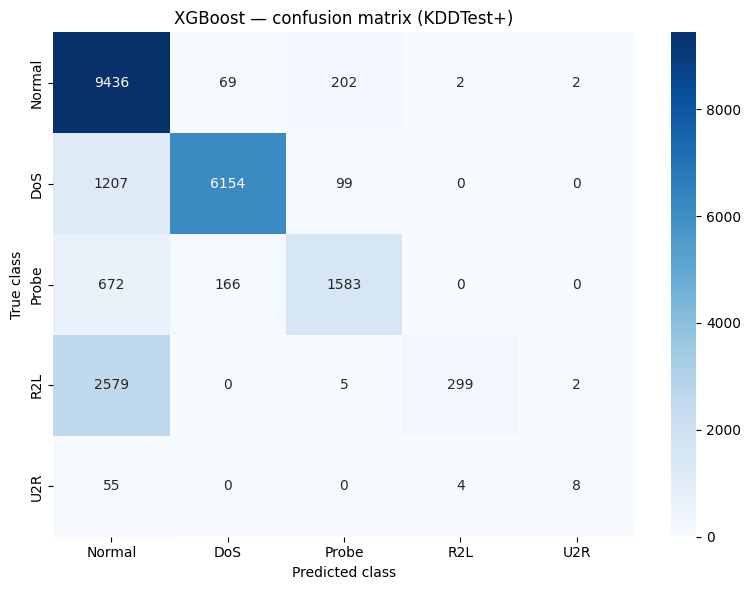

In [29]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_macro_precision = precision_score(
    y_test, xgb_pred, average="macro", labels=category_order, zero_division=0
)
xgb_macro_recall = recall_score(
    y_test, xgb_pred, average="macro", labels=category_order, zero_division=0
)
xgb_macro_f1 = f1_score(
    y_test, xgb_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Accuracy:        {xgb_accuracy:.4f}")
print(f"Macro precision: {xgb_macro_precision:.4f}")
print(f"Macro recall:    {xgb_macro_recall:.4f}")
print(f"Macro F1:        {xgb_macro_f1:.4f}")
print()
print("Classification report (XGBoost, test set):")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

xgb_cm = confusion_matrix(y_test, xgb_pred, labels=category_order)
xgb_cm_df = pd.DataFrame(xgb_cm, index=category_order, columns=category_order)
print("Confusion matrix (rows = true, columns = predicted):")
display(xgb_cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    xgb_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)
plt.title("XGBoost — confusion matrix (KDDTest+)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Final model comparison

**Macro F1** is the primary ranking metric: it averages the five class F1 scores equally, so rare classes (R2L, U2R) are not hidden by the large Normal and DoS counts. Accuracy is reported but is not the ranking rule.

The table reuses the already computed Logistic Regression and (scaled) Random Forest scores plus the new XGBoost scores. No earlier model is refit.

In [30]:
final_comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
        "Accuracy": [accuracy, rf_accuracy, xgb_accuracy],
        "Macro Precision": [macro_precision, rf_macro_precision, xgb_macro_precision],
        "Macro Recall": [macro_recall, rf_macro_recall, xgb_macro_recall],
        "Macro F1": [macro_f1, rf_macro_f1, xgb_macro_f1],
    }
).sort_values("Macro F1", ascending=False)

print("Test-set comparison, sorted by Macro F1 (primary metric):")
display(final_comparison_df.round(4))

Test-set comparison, sorted by Macro F1 (primary metric):


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.7893,0.6871,0.6727,0.6024
2,XGBoost,0.7754,0.8249,0.5347,0.5622
1,Random Forest,0.7388,0.7502,0.4744,0.4773


## XGBoost vs Previous Models

These figures are the observed KDDTest+ scores. Logistic Regression remains the **baseline**. XGBoost is **not** claimed to be better overall: its Macro F1 is **lower** than Logistic Regression.

**Headline scores**

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.7893 | 0.6871 | 0.6727 | **0.6024** |
| XGBoost | 0.7754 | 0.8249 | 0.5347 | **0.5622** |
| Random Forest (scaled) | 0.7388 | 0.7502 | 0.4744 | **0.4773** |

**Macro F1 vs Logistic Regression.** XGBoost Macro F1 is **0.5622**, which does **not** improve on Logistic Regression (**0.6024**). Accuracy is also lower (**0.7754** vs **0.7893**). Macro precision is higher (**0.8249** vs **0.6871**); macro recall is lower (**0.5347** vs **0.6727**). Ranking by our primary metric, Logistic Regression still leads.

**Minority-class recall vs Logistic Regression.** It did **not** improve.

- **R2L recall:** XGBoost **0.1036** vs Logistic Regression **0.2215** (and vs Random Forest **0.0045**). XGBoost correctly classified **299 of 2885** R2L rows. The confusion matrix shows **2579** true R2L rows predicted **Normal**.
- **U2R recall:** XGBoost **0.1194** vs Logistic Regression **0.5522** (and vs Random Forest **0.0299**). XGBoost correctly classified **8 of 67** U2R rows. **55** true U2R rows were predicted **Normal**. U2R precision is higher than Logistic Regression (**0.6667** vs **0.0796**), from few U2R predictions.

**Confusion matrix (XGBoost, observed).** Stronger diagonals for **Normal** (9436) and **DoS** (6154). **Probe** has 1583 correct, with 672 predicted Normal. The main error pattern is still **rare attacks labeled Normal**, especially R2L.

**Is the extra complexity justified by these results?** Not on Macro F1 or on R2L/U2R recall, which are the scores we care about under imbalance. XGBoost beat **this** Random Forest configuration on Macro F1 (0.5622 vs 0.4773) and on R2L/U2R recall, but it did **not** beat the Logistic Regression baseline. That is a result for **this** XGBoost setting (`n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, …), not a claim about all boosting setups.

## Final Baseline Model Comparison

Observed KDDTest+ scores for the three **baseline** configurations (no extra imbalance method, no extra tuning):

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.7893 | 0.6871 | 0.6727 | **0.6024** |
| XGBoost | 0.7754 | 0.8249 | 0.5347 | 0.5622 |
| Random Forest | 0.7388 | 0.7502 | 0.4744 | 0.4773 |

**Primary metric.** **Logistic Regression currently has the highest Macro F1 (0.6024).** Macro F1 is the ranking metric because the five classes are **highly imbalanced**. Accuracy counts every **row** equally, so Normal and DoS dominate. Macro F1 averages the five class F1 scores **equally**, so R2L and U2R are not hidden by the majority classes. That is a statement about how the metric is defined, not a claim that Macro F1 is the only useful score.

**XGBoost precision vs recall (observed).** XGBoost has the **highest Macro Precision (0.8249)** but **lower Macro Recall (0.5347)** than Logistic Regression (**0.6727**). On minority classes:

- R2L: precision **98.03%**, recall **10.36%**
- U2R: precision **66.67%**, recall **11.94%**

When XGBoost predicts R2L or U2R it is often correct, but it misses most true R2L and U2R rows. High minority precision does not offset that low recall in Macro F1.

**Random Forest (observed).** Random Forest has the **weakest Macro F1 (0.4773)**, and the lowest accuracy and macro recall of the three.

**R2L recall across models (observed).** XGBoost **improves R2L recall relative to Random Forest**, but **not relative to Logistic Regression** (XGBoost 10.36% vs Logistic Regression 22.15%).

**What these results do not show.** They do **not** show that Logistic Regression is universally superior, or that tree ensembles cannot work on NSL-KDD. They show that **these specific baseline settings**, on this train/test split, rank Logistic Regression first on Macro F1.

**Possible explanation (not proven).** Severe class imbalance, documented in Day 1 EDA, is a **likely contributing factor** to weak R2L/U2R recall—especially for models that rarely predict those classes. That is a hypothesis, not a demonstrated sole cause.

**Next.** Class-imbalance handling will be investigated next, still comparing against this Logistic Regression baseline.

## Day 3 — Class Imbalance: Class-Weighted Models

Day 2 baselines are **not** modified. This section studies **class weighting**.

### 1. Training counts are highly imbalanced

KDDTrain+ five-class counts:

| Class | Training rows |
|---|---:|
| Normal | 67,343 |
| DoS | 45,927 |
| Probe | 11,656 |
| R2L | 995 |
| U2R | 52 |

Normal and DoS dominate. R2L is under 1%. U2R is 52 rows.

### 2. Why imbalance can hide rare attacks

Most training updates come from majority classes. A classifier can get a high overall score by fitting Normal and DoS well and rarely predicting R2L or U2R. That shows up as high accuracy and weak minority recall.

### 3. Why accuracy is not enough

Accuracy is the fraction of **rows** that are correct. With this mix, correct Normal/DoS predictions outweigh missed R2L/U2R. We still report accuracy, but we rank with **macro** recall/F1 and **per-class** recall.

### 4. What class weighting does

- It does **not** create new rows (that would be resampling / SMOTE).
- It gives **higher training importance** to minority classes in the loss / split criterion.
- `class_weight="balanced"` sets weights from training frequencies (inversely proportional to class counts).

### 5. Why weighting before SMOTE

It is simpler, adds no synthetic samples, and is a controlled change of the **loss weights** only. If it is enough, we can avoid resampling complexity.

**Important about Day 2.** The original Logistic Regression and Random Forest already used `class_weight="balanced"`. Those results stay as **baseline**. Day 3 adds:

- **New class-weighted** pipelines (the setting requested below; same idea as Day 2)
- **New unweighted** controls (`class_weight` left as the sklearn default `None`) so we can see what weighting changes

XGBoost is not refit here. SMOTE is not used.

## Unweighted controls (new)

Same `preprocessor`, `X_train`, `y_train`, `X_test`, and `y_test`. No `class_weight`. These do **not** replace the Day 2 models.

In [31]:
lr_unweighted_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)
lr_unweighted_pipeline.fit(X_train, y_train)
lr_unweighted_pred = lr_unweighted_pipeline.predict(X_test)

rf_unweighted_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
rf_unweighted_pipeline.fit(X_train, y_train)
rf_unweighted_pred = rf_unweighted_pipeline.predict(X_test)

print("Unweighted Logistic Regression and Random Forest fitted on train only.")

Unweighted Logistic Regression and Random Forest fitted on train only.


## Class-weighted experiments (new)

Same data and `preprocessor` as Day 2. New pipeline objects so Day 2 `logistic_pipeline` and `random_forest_pipeline` are unchanged.

Logistic Regression fitting may take a few minutes.

In [32]:
lr_class_weighted_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)
lr_class_weighted_pipeline.fit(X_train, y_train)
lr_class_weighted_pred = lr_class_weighted_pipeline.predict(X_test)

rf_class_weighted_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
rf_class_weighted_pipeline.fit(X_train, y_train)
rf_class_weighted_pred = rf_class_weighted_pipeline.predict(X_test)

print("Class-weighted Logistic Regression and Random Forest fitted on train only.")
print("Original logistic_pipeline and random_forest_pipeline were not overwritten.")

Class-weighted Logistic Regression and Random Forest fitted on train only.
Original logistic_pipeline and random_forest_pipeline were not overwritten.


## Day 3 test metrics

Helper used only to print the same scores for each **new** prediction array. Day 2 `y_pred` / `rf_pred` are left as they are.

Logistic Regression — unweighted (new)
Accuracy:        0.7604
Macro precision: 0.7563
Macro recall:    0.5537
Macro F1:        0.5679

              precision    recall  f1-score   support

      Normal     0.6643    0.9302    0.7751      9711
         DoS     0.9204    0.8295    0.8726      7460
       Probe     0.8753    0.7712    0.8199      2421
         R2L     0.5714    0.0139    0.0271      2885
         U2R     0.7500    0.2239    0.3448        67

    accuracy                         0.7604     22544
   macro avg     0.7563    0.5537    0.5679     22544
weighted avg     0.7601    0.7604    0.7152     22544



,Normal,DoS,Probe,R2L,U2R
Normal,9033,416,256,2,4
DoS,1267,6188,5,0,0
Probe,413,114,1867,27,0
R2L,2836,3,5,40,1
U2R,49,2,0,1,15


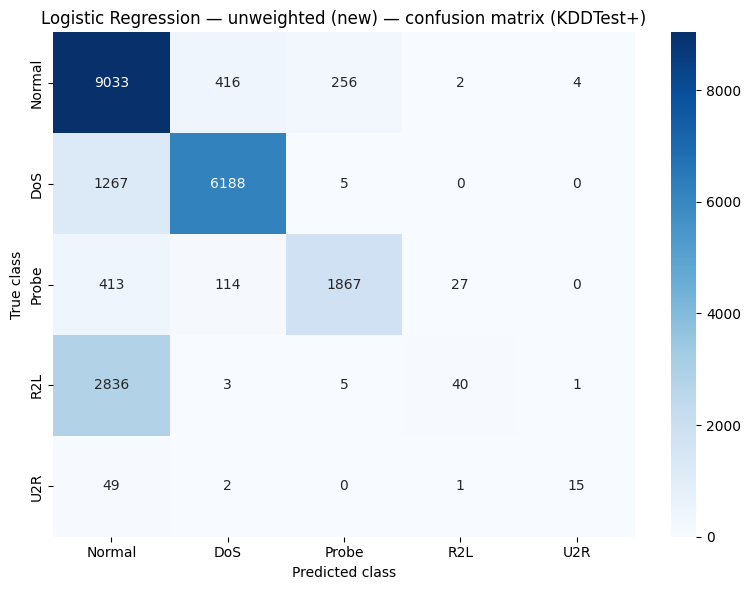

Random Forest — unweighted (new)
Accuracy:        0.7406
Macro precision: 0.8308
Macro recall:    0.4944
Macro F1:        0.5149

              precision    recall  f1-score   support

      Normal     0.6408    0.9733    0.7728      9711
         DoS     0.9607    0.7543    0.8451      7460
       Probe     0.8214    0.6002    0.6936      2421
         R2L     0.9812    0.0544    0.1031      2885
         U2R     0.7500    0.0896    0.1600        67

    accuracy                         0.7406     22544
   macro avg     0.8308    0.4944    0.5149     22544
weighted avg     0.8100    0.7406    0.7007     22544



,Normal,DoS,Probe,R2L,U2R
Normal,9452,67,191,0,1
DoS,1710,5627,123,0,0
Probe,805,163,1453,0,0
R2L,2725,0,2,157,1
U2R,58,0,0,3,6


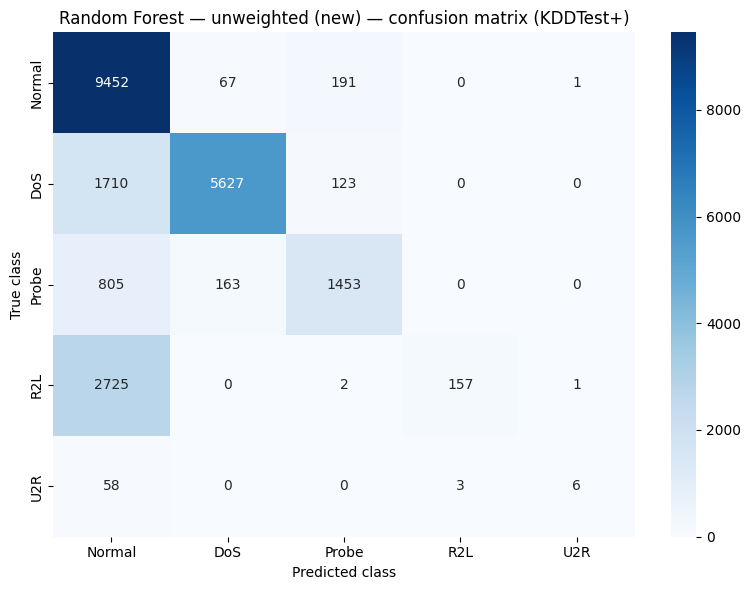

Logistic Regression — class weighted (new)
Accuracy:        0.7893
Macro precision: 0.6871
Macro recall:    0.6727
Macro F1:        0.6024

              precision    recall  f1-score   support

      Normal     0.7320    0.9140    0.8129      9711
         DoS     0.9190    0.8304    0.8725      7460
       Probe     0.8223    0.8451    0.8336      2421
         R2L     0.8826    0.2215    0.3541      2885
         U2R     0.0796    0.5522    0.1391        67

    accuracy                         0.7893     22544
   macro avg     0.6871    0.6727    0.6024     22544
weighted avg     0.8209    0.7893    0.7741     22544



,Normal,DoS,Probe,R2L,U2R
Normal,8876,416,348,34,37
DoS,1190,6195,73,0,2
Probe,205,127,2046,37,6
R2L,1839,3,21,639,383
U2R,16,0,0,14,37


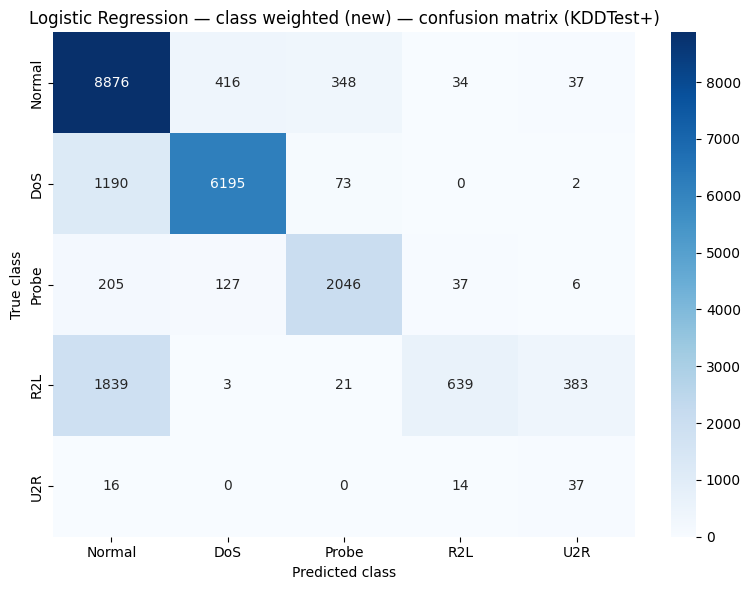

Random Forest — class weighted (new)
Accuracy:        0.7388
Macro precision: 0.7502
Macro recall:    0.4744
Macro F1:        0.4773

              precision    recall  f1-score   support

      Normal     0.6375    0.9738    0.7706      9711
         DoS     0.9614    0.7704    0.8553      7460
       Probe     0.8399    0.5936    0.6955      2421
         R2L     0.8125    0.0045    0.0090      2885
         U2R     0.5000    0.0299    0.0563        67

    accuracy                         0.7388     22544
   macro avg     0.7502    0.4744    0.4773     22544
weighted avg     0.7884    0.7388    0.6910     22544



,Normal,DoS,Probe,R2L,U2R
Normal,9457,67,186,0,1
DoS,1628,5747,85,0,0
Probe,820,164,1437,0,0
R2L,2868,0,3,13,1
U2R,62,0,0,3,2


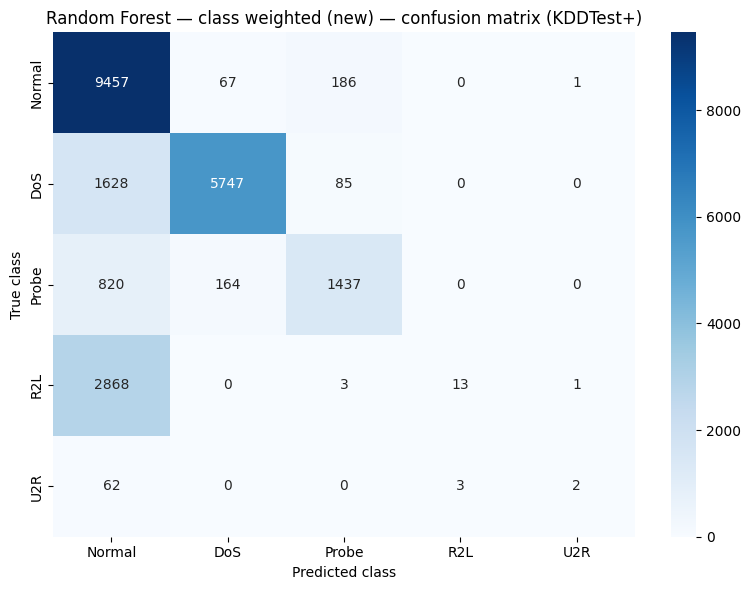

In [33]:
def evaluate_predictions(title, y_hat):
    acc = accuracy_score(y_test, y_hat)
    p = precision_score(
        y_test, y_hat, average="macro", labels=category_order, zero_division=0
    )
    r = recall_score(
        y_test, y_hat, average="macro", labels=category_order, zero_division=0
    )
    f1 = f1_score(
        y_test, y_hat, average="macro", labels=category_order, zero_division=0
    )
    per_class_recall = recall_score(
        y_test, y_hat, labels=category_order, average=None, zero_division=0
    )
    print(title)
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {p:.4f}")
    print(f"Macro recall:    {r:.4f}")
    print(f"Macro F1:        {f1:.4f}")
    print()
    print(classification_report(y_test, y_hat, labels=category_order, digits=4, zero_division=0))
    cm = confusion_matrix(y_test, y_hat, labels=category_order)
    cm_df = pd.DataFrame(cm, index=category_order, columns=category_order)
    display(cm_df)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
    plt.title(f"{title} — confusion matrix (KDDTest+)")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.show()
    return {
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "r2l_recall": per_class_recall[category_order.index("R2L")],
        "u2r_recall": per_class_recall[category_order.index("U2R")],
    }


lr_unweighted_metrics = evaluate_predictions(
    "Logistic Regression — unweighted (new)", lr_unweighted_pred
)
rf_unweighted_metrics = evaluate_predictions(
    "Random Forest — unweighted (new)", rf_unweighted_pred
)
lr_class_weighted_metrics = evaluate_predictions(
    "Logistic Regression — class weighted (new)", lr_class_weighted_pred
)
rf_class_weighted_metrics = evaluate_predictions(
    "Random Forest — class weighted (new)", rf_class_weighted_pred
)

lr_baseline_r2l = recall_score(
    y_test, y_pred, labels=category_order, average=None, zero_division=0
)[category_order.index("R2L")]
lr_baseline_u2r = recall_score(
    y_test, y_pred, labels=category_order, average=None, zero_division=0
)[category_order.index("U2R")]
rf_baseline_r2l = recall_score(
    y_test, rf_pred, labels=category_order, average=None, zero_division=0
)[category_order.index("R2L")]
rf_baseline_u2r = recall_score(
    y_test, rf_pred, labels=category_order, average=None, zero_division=0
)[category_order.index("U2R")]

## Comparison tables

**Baseline** rows use Day 2 variables (`accuracy`, `y_pred`, `rf_accuracy`, `rf_pred`). They already used `class_weight="balanced"`.

**Class weighted** rows are the new Day 3 pipelines with `class_weight="balanced"`.

**Unweighted** rows are the new controls with no class weights.

In [34]:
day3_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression — baseline",
            "Logistic Regression — class weighted",
            "Logistic Regression — unweighted",
            "Random Forest — baseline",
            "Random Forest — class weighted",
            "Random Forest — unweighted",
        ],
        "Accuracy": [
            accuracy,
            lr_class_weighted_metrics["accuracy"],
            lr_unweighted_metrics["accuracy"],
            rf_accuracy,
            rf_class_weighted_metrics["accuracy"],
            rf_unweighted_metrics["accuracy"],
        ],
        "Macro Precision": [
            macro_precision,
            lr_class_weighted_metrics["macro_precision"],
            lr_unweighted_metrics["macro_precision"],
            rf_macro_precision,
            rf_class_weighted_metrics["macro_precision"],
            rf_unweighted_metrics["macro_precision"],
        ],
        "Macro Recall": [
            macro_recall,
            lr_class_weighted_metrics["macro_recall"],
            lr_unweighted_metrics["macro_recall"],
            rf_macro_recall,
            rf_class_weighted_metrics["macro_recall"],
            rf_unweighted_metrics["macro_recall"],
        ],
        "Macro F1": [
            macro_f1,
            lr_class_weighted_metrics["macro_f1"],
            lr_unweighted_metrics["macro_f1"],
            rf_macro_f1,
            rf_class_weighted_metrics["macro_f1"],
            rf_unweighted_metrics["macro_f1"],
        ],
    }
)
print("Overall comparison (KDDTest+):")
display(day3_comparison_df.round(4))

minority_recall_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression — baseline",
            "Logistic Regression — class weighted",
            "Logistic Regression — unweighted",
            "Random Forest — baseline",
            "Random Forest — class weighted",
            "Random Forest — unweighted",
        ],
        "R2L Recall": [
            lr_baseline_r2l,
            lr_class_weighted_metrics["r2l_recall"],
            lr_unweighted_metrics["r2l_recall"],
            rf_baseline_r2l,
            rf_class_weighted_metrics["r2l_recall"],
            rf_unweighted_metrics["r2l_recall"],
        ],
        "U2R Recall": [
            lr_baseline_u2r,
            lr_class_weighted_metrics["u2r_recall"],
            lr_unweighted_metrics["u2r_recall"],
            rf_baseline_u2r,
            rf_class_weighted_metrics["u2r_recall"],
            rf_unweighted_metrics["u2r_recall"],
        ],
    }
)
print("Minority-class recall (KDDTest+):")
display(minority_recall_df.round(4))

Overall comparison (KDDTest+):


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression — baseline,0.7893,0.6871,0.6727,0.6024
1,Logistic Regression — class weighted,0.7893,0.6871,0.6727,0.6024
2,Logistic Regression — unweighted,0.7604,0.7563,0.5537,0.5679
3,Random Forest — baseline,0.7388,0.7502,0.4744,0.4773
4,Random Forest — class weighted,0.7388,0.7502,0.4744,0.4773
5,Random Forest — unweighted,0.7406,0.8308,0.4944,0.5149


Minority-class recall (KDDTest+):


,Model,R2L Recall,U2R Recall
0,Logistic Regression — baseline,0.2215,0.5522
1,Logistic Regression — class weighted,0.2215,0.5522
2,Logistic Regression — unweighted,0.0139,0.2239
3,Random Forest — baseline,0.0045,0.0299
4,Random Forest — class weighted,0.0045,0.0299
5,Random Forest — unweighted,0.0544,0.0896


## Class Weighting Results

These comments use the observed test numbers. Day 2 Logistic Regression and Random Forest **already** used `class_weight="balanced"`, so **baseline vs new class-weighted** is a replication of the same setting, not a new treatment.

**Baseline vs new class-weighted (same setting).**  
The new `class_weight="balanced"` pipelines match Day 2 (Logistic Regression Macro F1 **0.6024**, Random Forest Macro F1 **0.4773**, within rounding / solver noise). That pair does **not** show an improvement over baseline, because baseline was already class-weighted.

**What weighting changes vs the unweighted controls (the actual contrast).**

Logistic Regression:

| Setting | Accuracy | Macro Precision | Macro Recall | Macro F1 | R2L Recall | U2R Recall |
|---|---:|---:|---:|---:|---:|---:|
| Unweighted (new) | 0.7604 | 0.7563 | 0.5537 | 0.5679 | 0.0139 | 0.2239 |
| Class weighted (Day 2 / new) | 0.7893 | 0.6871 | 0.6727 | **0.6024** | **0.2215** | **0.5522** |

For Logistic Regression, class weighting **improved Macro F1**, **improved Macro Recall**, **improved R2L recall**, **improved U2R recall**, and **accuracy also rose**. Macro precision **fell** (0.7563 → 0.6871): a **precision/recall tradeoff**. Weighting made rare-class recall much higher (R2L 0.0139 → 0.2215; U2R 0.2239 → 0.5522).

Random Forest:

| Setting | Accuracy | Macro Precision | Macro Recall | Macro F1 | R2L Recall | U2R Recall |
|---|---:|---:|---:|---:|---:|---:|
| Unweighted (new) | 0.7406 | 0.8308 | 0.4944 | **0.5149** | **0.0544** | **0.0896** |
| Class weighted (Day 2 / new) | 0.7388 | 0.7502 | 0.4744 | 0.4773 | 0.0045 | 0.0299 |

For **this** Random Forest configuration, class weighting did **not** improve Macro F1 or Macro Recall. Accuracy was similar (0.7406 vs 0.7388). R2L and U2R recall were **worse** with weighting. Macro precision was higher without weighting. So weighting is **not** shown to help this forest.

**Carry forward?**  
Class weighting appears **useful enough to keep for Logistic Regression** (higher Macro F1 and minority recall than unweighted). It does **not** appear useful for this Random Forest setting. These are still baseline-style runs: no SMOTE, no extra tuning. Imbalance is a **likely** reason unweighted LR missed R2L; that is not proven as the only cause. SMOTE is not implemented in this section.

## Day 3 — Minority-Class Error Analysis

No new model is trained. The matrix below is rebuilt from the **existing** class-weighted Logistic Regression predictions (`lr_class_weighted_pred`) on KDDTest+.

Rows = **actual** class. Columns = **predicted** class. Order: Normal, DoS, Probe, R2L, U2R.

In [35]:
lr_weighted_error_cm = confusion_matrix(
    y_test, lr_class_weighted_pred, labels=category_order
)
lr_weighted_error_cm_df = pd.DataFrame(
    lr_weighted_error_cm,
    index=[f"Actual {c}" for c in category_order],
    columns=[f"Predicted {c}" for c in category_order],
)

print("Class-weighted Logistic Regression — confusion matrix (KDDTest+)")
print("Rows = actual class. Columns = predicted class.")
display(lr_weighted_error_cm_df)

print("Actual R2L row (where those 2885 samples were predicted):")
display(lr_weighted_error_cm_df.loc[["Actual R2L"]])
print("Actual U2R row (where those 67 samples were predicted):")
display(lr_weighted_error_cm_df.loc[["Actual U2R"]])

Class-weighted Logistic Regression — confusion matrix (KDDTest+)
Rows = actual class. Columns = predicted class.


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual Normal,8876,416,348,34,37
Actual DoS,1190,6195,73,0,2
Actual Probe,205,127,2046,37,6
Actual R2L,1839,3,21,639,383
Actual U2R,16,0,0,14,37


Actual R2L row (where those 2885 samples were predicted):


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual R2L,1839,3,21,639,383


Actual U2R row (where those 67 samples were predicted):


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual U2R,16,0,0,14,37


## Minority-class errors (observed counts only)

These counts are from the class-weighted Logistic Regression confusion matrix already produced (same numbers as the Day 2 Logistic Regression run, which used the same `class_weight="balanced"` setting):

| Actual \ Predicted | Normal | DoS | Probe | R2L | U2R | Row total |
|---|---:|---:|---:|---:|---:|---:|
| **R2L** | 1839 | 3 | 21 | 639 | 383 | 2885 |
| **U2R** | 16 | 0 | 0 | 14 | 37 | 67 |

**1. Where actual R2L flows were predicted.**  
The largest destination is **Normal (1839)**. Next is **R2L (639)** (correct). Next is **U2R (383)**. Probe received 21 and DoS received 3.

**2. Where actual U2R flows were predicted.**  
The largest destination is **U2R (37)** (correct). Next is **Normal (16)**. Next is **R2L (14)**. DoS and Probe received 0.

**3. Correct classifications.**  
- R2L: **639** of **2885**  
- U2R: **37** of **67**

**4. Recall for a class.**

\[
\text{recall} = \frac{\text{true positives}}{\text{all actual samples of that class}}
\]

So R2L recall = \(639 / 2885 \approx 0.2215\). U2R recall = \(37 / 67 \approx 0.5522\). The 1839 actual R2L predicted as Normal, and the 16 + 14 actual U2R predicted as Normal or R2L, are the misses that lower those recalls.

This section does not add a cause for those misses, and it does not add SMOTE, threshold changes, or a new model.

## Day 3 — Understanding Balanced Class Weights

No model is trained here. We only compute the weights that `class_weight="balanced"` would assign from the **existing** `y_train` labels.

sklearn’s formula is:

`weight(class) = n_samples / (n_classes × n_samples_in_class)`

So the weight is **inversely related** to how many training rows that class has.

In [36]:
from sklearn.utils.class_weight import compute_class_weight

balanced_classes = np.array(category_order)
balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=balanced_classes,
    y=y_train,
)
training_counts = y_train.value_counts().reindex(category_order)

balanced_weight_df = pd.DataFrame(
    {
        "Class": category_order,
        "Training Samples": training_counts.values,
        "Balanced Class Weight": balanced_weights,
    }
)
print("Effective class_weight=\"balanced\" values from y_train:")
display(balanced_weight_df)

Effective class_weight="balanced" values from y_train:


,Class,Training Samples,Balanced Class Weight
0,Normal,67343,0.374124
1,DoS,45927,0.548579
2,Probe,11656,2.161513
3,R2L,995,25.321206
4,U2R,52,484.511538


## What these weights mean

Observed from `y_train` with `compute_class_weight(class_weight="balanced")`:

| Class | Training Samples | Balanced Class Weight |
|---|---:|---:|
| Normal | 67,343 | 0.37 |
| DoS | 45,927 | 0.55 |
| Probe | 11,656 | 2.16 |
| R2L | 995 | 25.32 |
| U2R | 52 | 484.51 |

- `class_weight="balanced"` gives **higher weight to classes with fewer training examples**.
- The weights are **inversely related to class frequency**: more rows → smaller weight.
- **Largest weight: U2R** (about **484.5**), the rarest class (52 rows).
- **Smallest weight: Normal** (about **0.37**), the most common class (67,343 rows).
- U2R’s weight is much larger than Normal’s because Normal appears thousands of times more often in `y_train`. The balanced formula divides by class count, so 52 rows produce a far larger multiplier than 67,343 rows. That up-weights each U2R example in training; it does **not** add new samples.

No existing predictions or models were changed. SMOTE is not used here.

## Day 3 — Probability and Precision-Recall Analysis

This section is **analysis only**. The class-weighted Logistic Regression pipeline is **not** refit. Default `predict` labels are not changed.

We use `lr_class_weighted_pipeline.predict_proba(X_test)` on KDDTest+.

sklearn stores class order in `classes_` (often alphabetical: DoS, Normal, Probe, R2L, U2R). Probability **column i** belongs to `classes_[i]`. We look up the **R2L column** from that array rather than assuming column 3.

predict_proba shape: (22544, 5)
Expected (n_test, 5): (22544, 5)

Model class order (probability columns):


,column_index,class_name
0,0,DoS
1,1,Normal
2,2,Probe
3,3,R2L
4,4,U2R


Probability row sums: min = 0.9999999999999996 , max = 1.0000000000000004
All rows sum to ~1: True

R2L probability column index: 3
Positive (actual R2L) test samples: 2885
Negative test samples: 19659
R2L Average Precision (AP): 0.5862


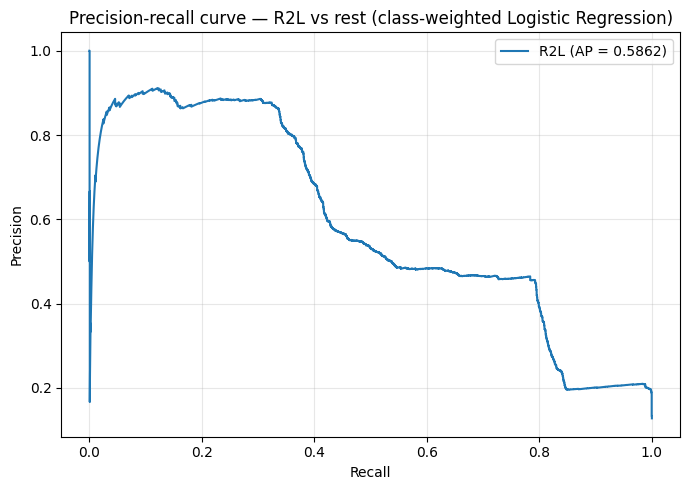

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score

lr_proba = lr_class_weighted_pipeline.predict_proba(X_test)

print("predict_proba shape:", lr_proba.shape)
print("Expected (n_test, 5):", (X_test.shape[0], 5))
print()

lr_proba_class_order = lr_class_weighted_pipeline.classes_
print("Model class order (probability columns):")
display(
    pd.DataFrame(
        {
            "column_index": range(len(lr_proba_class_order)),
            "class_name": lr_proba_class_order,
        }
    )
)

row_sums = lr_proba.sum(axis=1)
print("Probability row sums: min =", row_sums.min(), ", max =", row_sums.max())
print("All rows sum to ~1:", np.allclose(row_sums, 1.0, atol=1e-6))

r2l_col = list(lr_proba_class_order).index("R2L")
r2l_scores = lr_proba[:, r2l_col]
y_r2l_binary = (y_test == "R2L").astype(int)

print()
print("R2L probability column index:", r2l_col)
print("Positive (actual R2L) test samples:", y_r2l_binary.sum())
print("Negative test samples:", (1 - y_r2l_binary).sum())

r2l_precision, r2l_recall, r2l_thresholds = precision_recall_curve(
    y_r2l_binary, r2l_scores
)
r2l_average_precision = average_precision_score(y_r2l_binary, r2l_scores)

print(f"R2L Average Precision (AP): {r2l_average_precision:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(r2l_recall, r2l_precision, label=f"R2L (AP = {r2l_average_precision:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curve — R2L vs rest (class-weighted Logistic Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## How to read this probability analysis

**What `predict_proba` is.**  
For each test connection the model outputs **five numbers**, one per class. Each number is the model’s estimated probability that the row belongs to that class. The five values for one row **sum to 1**. The usual `predict` label is whichever class has the **largest** probability. We did not change that rule here; we only inspected the probabilities.

**Why R2L vs rest.**  
Average Precision and the precision-recall curve are defined for a **binary** positive/negative split. To study R2L as a rare attack, we set:

- positive = actual class is **R2L**
- negative = actual class is Normal, DoS, Probe, or U2R
- score = the **R2L** probability column

That is one-vs-rest: we ask how well the R2L score ranks true R2L rows above everything else, without retraining.

**What the curve shows.**  
Each point is a different threshold on the R2L probability (high threshold → fewer R2L calls, usually higher precision and lower recall). The curve is precision vs recall as that threshold moves. **Average Precision (AP)** summarizes the curve (higher is better; 1.0 would mean perfect ranking of R2L vs the rest).

**Why this is more informative than accuracy for R2L.**  
R2L is a small slice of KDDTest+. Accuracy can stay high even if almost all R2L rows are called Normal. The PR curve and AP use the **R2L score** and the **R2L positives**, so they describe that rare class directly. They do not replace the five-class confusion matrix; they add a view of R2L ranking. SMOTE and new models are not used here.

## Day 3 — R2L Threshold Analysis

Analysis only. The class-weighted Logistic Regression pipeline is **not** refit. Default `predict` labels are **not** overwritten.

We reuse the existing `lr_proba` array. Model `classes_` order is DoS, Normal, Probe, **R2L**, U2R, so the R2L score is **column 3** (confirmed with `.index("R2L")`).

Binary ground truth: **1** if `y_test` is R2L, else **0**. A test row is called R2L at threshold \(t\) if its R2L probability is \(\ge t\).

R2L probability column index: 3
Class order: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
R2L one-vs-rest threshold sweep (class-weighted Logistic Regression, KDDTest+):


,threshold,precision,recall,F1,true positives,false positives,false negatives
0,0.1,0.780541,0.369844,0.501881,1067,300,1818
1,0.2,0.828836,0.340728,0.482928,983,203,1902
2,0.3,0.875468,0.324090,0.473058,935,133,1950
3,0.4,0.882029,0.277296,0.421941,800,107,2085
4,0.5,0.879056,0.206586,0.334550,596,82,2289
5,0.6,0.875969,0.156672,0.265804,452,64,2433
6,0.7,0.894397,0.143847,0.247835,415,49,2470
7,0.8,0.898148,0.134489,0.233946,388,44,2497
8,0.9,0.897436,0.097054,0.175164,280,32,2605


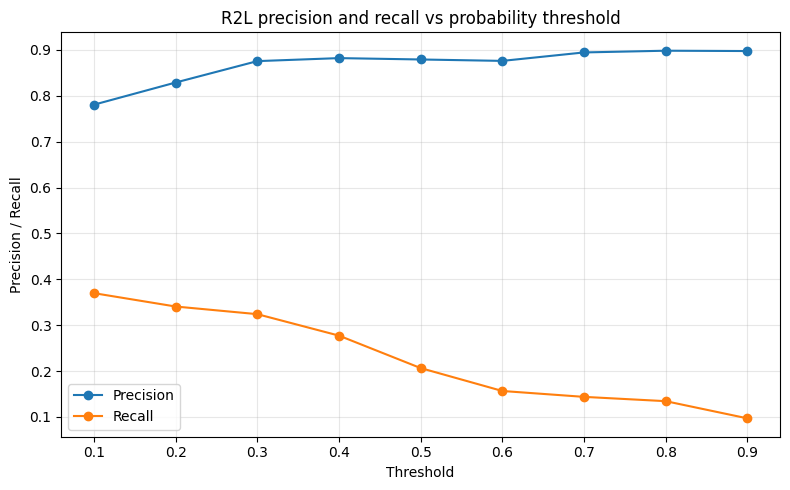

Highest R2L F1 among the listed thresholds:
  best threshold: 0.10
  precision:      0.7805
  recall:         0.3698
  F1:             0.5019

Default five-class predict() labels were not changed.


In [38]:
r2l_col_index = list(lr_class_weighted_pipeline.classes_).index("R2L")
r2l_probability = lr_proba[:, r2l_col_index]
y_r2l_positive = (y_test == "R2L").astype(int)

print("R2L probability column index:", r2l_col_index)
print("Class order:", list(lr_class_weighted_pipeline.classes_))

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
threshold_rows = []

for t in thresholds:
    called_r2l = r2l_probability >= t
    tp = int(((called_r2l == 1) & (y_r2l_positive == 1)).sum())
    fp = int(((called_r2l == 1) & (y_r2l_positive == 0)).sum())
    fn = int(((called_r2l == 0) & (y_r2l_positive == 1)).sum())
    precision_t = tp / (tp + fp) if (tp + fp) else 0.0
    recall_t = tp / (tp + fn) if (tp + fn) else 0.0
    f1_t = (
        (2 * precision_t * recall_t / (precision_t + recall_t))
        if (precision_t + recall_t)
        else 0.0
    )
    threshold_rows.append(
        {
            "threshold": t,
            "precision": precision_t,
            "recall": recall_t,
            "F1": f1_t,
            "true positives": tp,
            "false positives": fp,
            "false negatives": fn,
        }
    )

r2l_threshold_df = pd.DataFrame(threshold_rows).sort_values("threshold")
print("R2L one-vs-rest threshold sweep (class-weighted Logistic Regression, KDDTest+):")
display(r2l_threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(r2l_threshold_df["threshold"], r2l_threshold_df["precision"], marker="o", label="Precision")
plt.plot(r2l_threshold_df["threshold"], r2l_threshold_df["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.title("R2L precision and recall vs probability threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_row = r2l_threshold_df.loc[r2l_threshold_df["F1"].idxmax()]
print("Highest R2L F1 among the listed thresholds:")
print(f"  best threshold: {best_row['threshold']:.2f}")
print(f"  precision:      {best_row['precision']:.4f}")
print(f"  recall:         {best_row['recall']:.4f}")
print(f"  F1:             {best_row['F1']:.4f}")
print()
print("Default five-class predict() labels were not changed.")

## How to read the R2L threshold sweep

**Lowering the threshold** (for example 0.50 → 0.10) generally makes the detector **more sensitive** to R2L: more rows with a modest R2L probability are counted as positive. That can **raise recall** (fewer missed actual R2L rows) but also **raise false positives**, which **lowers precision**.

**Raising the threshold** (for example 0.50 → 0.90) generally does the **opposite**: fewer R2L calls, typically **higher precision** and **lower recall**.

The threshold is an **operating-point / policy** choice. It is **not** required to be 0.5. The value with the highest F1 in the table above is only the best among **these nine thresholds** on this test set; it is not automatically the right deployment rule.

We **analyzed** thresholds here. We did **not** change the model’s existing default `predict` labels or production behavior. SMOTE was not used.

## Day 3 — Validation Split for Threshold Selection

The original KDDTrain+ data is divided into a model-fitting subset and a validation subset. The validation subset is used for decisions such as threshold selection, while KDDTest+ remains untouched until final evaluation.

This cell only **splits** the existing `X_train` / `y_train`. It does **not** refit Logistic Regression, Random Forest, or XGBoost. `X_test` and `y_test` (KDDTest+) are not passed into `train_test_split` and are not overwritten.

Stratify on `y_train` so the 80/20 subsets keep similar five-class proportions. `random_state=42` makes the split repeatable.

In [40]:
from sklearn.model_selection import train_test_split

X_train_fit, X_validation, y_train_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42,
)

print("X_train_fit shape:", X_train_fit.shape)
print("X_validation shape:", X_validation.shape)
print("y_train_fit shape:", y_train_fit.shape)
print("y_validation shape:", y_validation.shape)
print()

print("y_train_fit class counts:")
display(y_train_fit.value_counts().reindex(category_order))
print("y_train_fit class percentages:")
display((y_train_fit.value_counts(normalize=True).reindex(category_order) * 100).round(4))
print()
print("y_validation class counts:")
display(y_validation.value_counts().reindex(category_order))
print("y_validation class percentages:")
display((y_validation.value_counts(normalize=True).reindex(category_order) * 100).round(4))
print()
print("KDDTest+ left unchanged:")
print("  X_test shape:", X_test.shape)
print("  y_test shape:", y_test.shape)
print()
print("No model was retrained in this section.")

X_train_fit shape: (100778, 41)
X_validation shape: (25195, 41)
y_train_fit shape: (100778,)
y_validation shape: (25195,)

y_train_fit class counts:


attack_category
Normal    53874
DoS       36741
Probe      9325
R2L         796
U2R          42
Name: count, dtype: int64

y_train_fit class percentages:


attack_category
Normal    53.4581
DoS       36.4574
Probe      9.2530
R2L        0.7899
U2R        0.0417
Name: proportion, dtype: float64


y_validation class counts:


attack_category
Normal    13469
DoS        9186
Probe      2331
R2L         199
U2R          10
Name: count, dtype: int64

y_validation class percentages:


attack_category
Normal    53.4590
DoS       36.4596
Probe      9.2518
R2L        0.7898
U2R        0.0397
Name: proportion, dtype: float64


KDDTest+ left unchanged:
  X_test shape: (22544, 41)
  y_test shape: (22544,)

No model was retrained in this section.


## Day 3 — Class-weighted Logistic Regression on the fitting subset

The original KDDTrain+ rows were split into **`X_train_fit` / `y_train_fit` (80%)** and **`X_validation` / `y_validation` (20%)**.

We fit a **new** class-weighted Logistic Regression pipeline on the fitting subset **only**. The validation subset is held out for later decisions (such as an R2L threshold). **KDDTest+ (`X_test`, `y_test`) is not used** for fitting or for this evaluation.

That separation matters: if we tuned a threshold on KDDTest+, the test score would no longer be an honest final check. Validation is for those choices; test stays last.

This pipeline is named `lr_validation_pipeline`. It does **not** replace Day 2 `logistic_pipeline` or Day 3 `lr_class_weighted_pipeline`. Preprocessing is a **new** `ColumnTransformer` (same design: OneHotEncoder + StandardScaler) fitted only on `X_train_fit`, so the Day 2 `preprocessor` object is not refit.

In [41]:
lr_validation_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

lr_validation_pipeline = Pipeline(
    [
        ("preprocessor", lr_validation_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

lr_validation_pipeline.fit(X_train_fit, y_train_fit)

print("Fitted lr_validation_pipeline on X_train_fit / y_train_fit only.")
print("Model class order (lr_validation_pipeline.classes_):")
print(lr_validation_pipeline.classes_)
print()
print("X_test / y_test were not used for fitting.")

y_validation_pred = lr_validation_pipeline.predict(X_validation)
y_validation_proba = lr_validation_pipeline.predict_proba(X_validation)

print("Validation predict_proba shape:", y_validation_proba.shape)

lr_val_accuracy = accuracy_score(y_validation, y_validation_pred)
lr_val_macro_precision = precision_score(
    y_validation, y_validation_pred, average="macro", labels=category_order, zero_division=0
)
lr_val_macro_recall = recall_score(
    y_validation, y_validation_pred, average="macro", labels=category_order, zero_division=0
)
lr_val_macro_f1 = f1_score(
    y_validation, y_validation_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Validation accuracy:        {lr_val_accuracy:.4f}")
print(f"Validation macro precision: {lr_val_macro_precision:.4f}")
print(f"Validation macro recall:    {lr_val_macro_recall:.4f}")
print(f"Validation macro F1:        {lr_val_macro_f1:.4f}")
print()
print("Validation classification report:")
print(
    classification_report(
        y_validation,
        y_validation_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

lr_val_cm = confusion_matrix(y_validation, y_validation_pred, labels=category_order)
lr_val_cm_df = pd.DataFrame(lr_val_cm, index=category_order, columns=category_order)
print("Validation confusion matrix (rows = actual, columns = predicted):")
display(lr_val_cm_df)

Fitted lr_validation_pipeline on X_train_fit / y_train_fit only.
Model class order (lr_validation_pipeline.classes_):
['DoS' 'Normal' 'Probe' 'R2L' 'U2R']

X_test / y_test were not used for fitting.
Validation predict_proba shape: (25195, 5)
Validation accuracy:        0.9668
Validation macro precision: 0.6567
Validation macro recall:    0.9528
Validation macro F1:        0.6985

Validation classification report:
              precision    recall  f1-score   support

      Normal     0.9963    0.9427    0.9688     13469
         DoS     0.9959    0.9986    0.9972      9186
       Probe     0.9246    0.9833    0.9530      2331
         R2L     0.3091    0.9397    0.4652       199
         U2R     0.0577    0.9000    0.1084        10

    accuracy                         0.9668     25195
   macro avg     0.6567    0.9528    0.6985     25195
weighted avg     0.9837    0.9668    0.9734     25195

Validation confusion matrix (rows = actual, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,12697,34,185,416,137
DoS,11,9173,2,0,0
Probe,30,4,2292,2,3
R2L,5,0,0,187,7
U2R,1,0,0,0,9


## Day 3 — R2L threshold analysis on the validation set

Thresholds are chosen using **`X_validation` / `y_validation` only**. **KDDTest+ is not used.** `lr_validation_pipeline` is not refit. Default five-class `predict()` is not changed.

`predict_proba` column order follows `lr_validation_pipeline.classes_`. The R2L column is looked up by name, not assumed to be index 3.

Validation probability shape: (25195, 5)
Class order (lr_validation_pipeline.classes_): ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
R2L probability column index: 3
Validation R2L positives: 199
Validation non-R2L: 24996
R2L one-vs-rest thresholds on VALIDATION only:


,threshold,precision,recall,F1,true positives,false positives,false negatives
0,0.05,0.163651,1.000000,0.281272,199,1017,0
1,0.10,0.187441,0.989950,0.315200,197,854,2
2,0.15,0.204357,0.989950,0.338779,197,767,2
3,0.20,0.222348,0.989950,0.363134,197,689,2
4,0.30,0.250965,0.979899,0.399590,195,582,4
5,0.40,0.287187,0.979899,0.444191,195,484,4
6,0.50,0.311148,0.939698,0.467500,187,414,12
7,0.60,0.340741,0.924623,0.497970,184,356,15
8,0.70,0.397778,0.899497,0.551618,179,271,20
9,0.80,0.491228,0.844221,0.621072,168,174,31


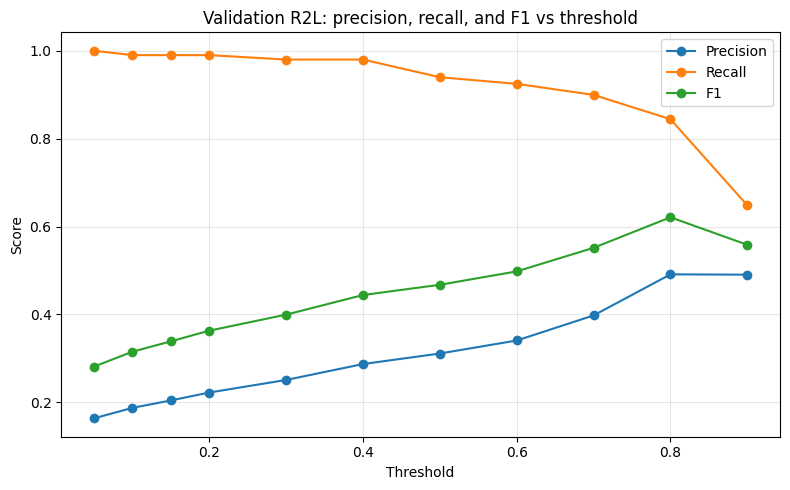

Highest validation R2L F1 among the listed thresholds:
  threshold: 0.80
  precision: 0.4912
  recall:    0.8442
  F1:        0.6211

Listed threshold closest to 80% R2L recall:
  threshold: 0.80
  precision: 0.4912
  recall:    0.8442
  F1:        0.6211

Precision/recall tradeoff (validation):
Lower thresholds typically raise R2L recall and false positives, which lowers precision.
Higher thresholds typically raise precision and miss more actual R2L (lower recall).
The best-F1 threshold above is a validation operating point only.
Default five-class predict() was not changed. KDDTest+ was not used.


In [42]:
validation_proba = lr_validation_pipeline.predict_proba(X_validation)

print("Validation probability shape:", validation_proba.shape)
print("Class order (lr_validation_pipeline.classes_):", list(lr_validation_pipeline.classes_))

val_r2l_col = list(lr_validation_pipeline.classes_).index("R2L")
print("R2L probability column index:", val_r2l_col)

val_r2l_scores = validation_proba[:, val_r2l_col]
y_validation_r2l = (y_validation == "R2L").astype(int)

print("Validation R2L positives:", int(y_validation_r2l.sum()))
print("Validation non-R2L:", int((1 - y_validation_r2l).sum()))

val_thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
val_threshold_rows = []

for t in val_thresholds:
    called_r2l = val_r2l_scores >= t
    tp = int(((called_r2l == 1) & (y_validation_r2l == 1)).sum())
    fp = int(((called_r2l == 1) & (y_validation_r2l == 0)).sum())
    fn = int(((called_r2l == 0) & (y_validation_r2l == 1)).sum())
    precision_t = tp / (tp + fp) if (tp + fp) else 0.0
    recall_t = tp / (tp + fn) if (tp + fn) else 0.0
    f1_t = (
        (2 * precision_t * recall_t / (precision_t + recall_t))
        if (precision_t + recall_t)
        else 0.0
    )
    val_threshold_rows.append(
        {
            "threshold": t,
            "precision": precision_t,
            "recall": recall_t,
            "F1": f1_t,
            "true positives": tp,
            "false positives": fp,
            "false negatives": fn,
        }
    )

val_r2l_threshold_df = pd.DataFrame(val_threshold_rows).sort_values("threshold")
print("R2L one-vs-rest thresholds on VALIDATION only:")
display(val_r2l_threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(val_r2l_threshold_df["threshold"], val_r2l_threshold_df["precision"], marker="o", label="Precision")
plt.plot(val_r2l_threshold_df["threshold"], val_r2l_threshold_df["recall"], marker="o", label="Recall")
plt.plot(val_r2l_threshold_df["threshold"], val_r2l_threshold_df["F1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation R2L: precision, recall, and F1 vs threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_f1_row = val_r2l_threshold_df.loc[val_r2l_threshold_df["F1"].idxmax()]
recall_80_row = val_r2l_threshold_df.iloc[
    (val_r2l_threshold_df["recall"] - 0.80).abs().argmin()
]

print("Highest validation R2L F1 among the listed thresholds:")
print(f"  threshold: {best_f1_row['threshold']:.2f}")
print(f"  precision: {best_f1_row['precision']:.4f}")
print(f"  recall:    {best_f1_row['recall']:.4f}")
print(f"  F1:        {best_f1_row['F1']:.4f}")
print()
print("Listed threshold closest to 80% R2L recall:")
print(f"  threshold: {recall_80_row['threshold']:.2f}")
print(f"  precision: {recall_80_row['precision']:.4f}")
print(f"  recall:    {recall_80_row['recall']:.4f}")
print(f"  F1:        {recall_80_row['F1']:.4f}")
if abs(recall_80_row["recall"] - 0.80) > 0.05:
    print("  Note: no listed threshold is within 0.05 of 0.80 recall; this is the closest.")

print()
print("Precision/recall tradeoff (validation):")
print("Lower thresholds typically raise R2L recall and false positives, which lowers precision.")
print("Higher thresholds typically raise precision and miss more actual R2L (lower recall).")
print("The best-F1 threshold above is a validation operating point only.")
print("Default five-class predict() was not changed. KDDTest+ was not used.")

## Validation threshold notes

Lowering the R2L probability threshold generally makes the detector more sensitive: recall can rise, but false positives often rise and precision falls. Raising it generally does the opposite.

The printed **best-F1** threshold is the best among the listed values on **validation**, not a required 0.5 default, and not a test-set result. The **~80% recall** row is the listed threshold whose validation recall is closest to 0.80, if one exists.

We have **not** applied this threshold to KDDTest+ and have **not** changed `predict()`. Next step (not in this cell) would be a frozen threshold evaluated once on test.

## Day 3 — Final KDDTest+ evaluation (locked R2L threshold 0.80)

The R2L one-vs-rest threshold **0.80** was chosen on **validation only** and is **locked**. We do **not** search for another threshold on KDDTest+.

`lr_validation_pipeline` is **not** refit. Day 2 results are **not** overwritten.

Two separate evaluations:

1. **Default five-class `predict()`** — the usual argmax over five class probabilities.
2. **Locked R2L one-vs-rest at 0.80** — a binary operating point on the R2L probability. This is **not** a replacement for the five-class predictor.

In [ ]:
LOCKED_R2L_THRESHOLD = 0.80

test_proba = lr_validation_pipeline.predict_proba(X_test)
print("test_proba shape:", test_proba.shape)
print("lr_validation_pipeline.classes_:", list(lr_validation_pipeline.classes_))
test_r2l_col = list(lr_validation_pipeline.classes_).index("R2L")
print("R2L probability column index:", test_r2l_col)
print()

test_default_pred = lr_validation_pipeline.predict(X_test)

test_default_accuracy = accuracy_score(y_test, test_default_pred)
test_default_macro_precision = precision_score(
    y_test, test_default_pred, average="macro", labels=category_order, zero_division=0
)
test_default_macro_recall = recall_score(
    y_test, test_default_pred, average="macro", labels=category_order, zero_division=0
)
test_default_macro_f1 = f1_score(
    y_test, test_default_pred, average="macro", labels=category_order, zero_division=0
)

print("=== Default five-class predict() on KDDTest+ ===")
print(f"Accuracy:        {test_default_accuracy:.4f}")
print(f"Macro precision: {test_default_macro_precision:.4f}")
print(f"Macro recall:    {test_default_macro_recall:.4f}")
print(f"Macro F1:        {test_default_macro_f1:.4f}")
print()
print(classification_report(y_test, test_default_pred, labels=category_order, digits=4, zero_division=0))
test_default_cm = confusion_matrix(y_test, test_default_pred, labels=category_order)
test_default_cm_df = pd.DataFrame(test_default_cm, index=category_order, columns=category_order)
print("Confusion matrix (rows = actual, columns = predicted):")
display(test_default_cm_df)

r2l_test_probability = test_proba[:, test_r2l_col]
y_test_r2l = (y_test == "R2L").astype(int)
r2l_test_pred = (r2l_test_probability >= LOCKED_R2L_THRESHOLD).astype(int)

r2l_tp = int(((r2l_test_pred == 1) & (y_test_r2l == 1)).sum())
r2l_fp = int(((r2l_test_pred == 1) & (y_test_r2l == 0)).sum())
r2l_fn = int(((r2l_test_pred == 0) & (y_test_r2l == 1)).sum())
r2l_locked_precision = r2l_tp / (r2l_tp + r2l_fp) if (r2l_tp + r2l_fp) else 0.0
r2l_locked_recall = r2l_tp / (r2l_tp + r2l_fn) if (r2l_tp + r2l_fn) else 0.0
r2l_locked_f1 = (
    (2 * r2l_locked_precision * r2l_locked_recall / (r2l_locked_precision + r2l_locked_recall))
    if (r2l_locked_precision + r2l_locked_recall)
    else 0.0
)

print()
print("=== Locked R2L one-vs-rest threshold 0.80 on KDDTest+ ===")
print("This is NOT a five-class prediction.")
print(f"Precision:        {r2l_locked_precision:.4f}")
print(f"Recall:           {r2l_locked_recall:.4f}")
print(f"F1:               {r2l_locked_f1:.4f}")
print(f"True positives:   {r2l_tp}")
print(f"False positives:  {r2l_fp}")
print(f"False negatives:  {r2l_fn}")

day2_r2l_scores = precision_score(
    y_test, y_pred, labels=["R2L"], average=None, zero_division=0
)[0]
day2_r2l_recall = recall_score(
    y_test, y_pred, labels=["R2L"], average=None, zero_division=0
)[0]
day2_r2l_f1 = f1_score(y_test, y_pred, labels=["R2L"], average=None, zero_division=0)[0]
val_model_r2l_precision = precision_score(
    y_test, test_default_pred, labels=["R2L"], average=None, zero_division=0
)[0]
val_model_r2l_recall = recall_score(
    y_test, test_default_pred, labels=["R2L"], average=None, zero_division=0
)[0]
val_model_r2l_f1 = f1_score(
    y_test, test_default_pred, labels=["R2L"], average=None, zero_division=0
)[0]

final_eval_df = pd.DataFrame(
    {
        "Evaluation": [
            "Day 2 class-weighted LR (five-class predict)",
            "Validation-trained LR (five-class predict on KDDTest+)",
            "Locked R2L threshold 0.80 (one-vs-rest on KDDTest+)",
        ],
        "Accuracy": [accuracy, test_default_accuracy, np.nan],
        "Macro Precision": [macro_precision, test_default_macro_precision, np.nan],
        "Macro Recall": [macro_recall, test_default_macro_recall, np.nan],
        "Macro F1": [macro_f1, test_default_macro_f1, np.nan],
        "R2L Precision": [day2_r2l_scores, val_model_r2l_precision, r2l_locked_precision],
        "R2L Recall": [day2_r2l_recall, val_model_r2l_recall, r2l_locked_recall],
        "R2L F1": [day2_r2l_f1, val_model_r2l_f1, r2l_locked_f1],
    }
)
print()
print("Compact comparison (NaN = not a five-class evaluation):")
display(final_eval_df.round(4))
print()
print("Threshold remained LOCKED at", LOCKED_R2L_THRESHOLD)
print("No additional threshold search was performed on KDDTest+.")

## Final evaluation interpretation

**Method.** The R2L threshold **0.80** was selected on the **validation** split only, then **frozen**. KDDTest+ was used **once** for final scores. We did not retune 0.80 after seeing test results. The locked rule is **one-vs-rest R2L vs rest**; it does **not** replace five-class `predict()`.

**Observed KDDTest+ numbers** (same setup as the cell above):

| Evaluation | Accuracy | Macro F1 | R2L Precision | R2L Recall | R2L F1 |
|---|---:|---:|---:|---:|---:|
| Day 2 class-weighted LR, five-class `predict()` | 0.7893 | 0.6024 | 0.8826 | **0.2215** | 0.3541 |
| Validation-trained LR, five-class `predict()` | 0.7920 | 0.6041 | 0.8918 | 0.2343 | 0.3711 |
| Locked R2L threshold 0.80 (one-vs-rest) | — | — | 0.8916 | **0.1282** | 0.2242 |

Locked 0.80 on test: **TP = 370**, **FP = 45**, **FN = 2515** (2885 actual R2L).

**Did R2L recall improve vs Day 2?** **No.** Day 2 five-class R2L recall was **0.2215**. The locked 0.80 detector’s R2L recall is **0.1282** (lower). The validation-trained model’s **default** five-class R2L recall (0.2343) is close to Day 2, not a large gain.

**Precision / false positives.** Locked 0.80 keeps **high precision (~0.89)**, similar to Day 2’s R2L precision (0.88). False positives are **45**, fewer than Day 2’s five-class R2L false positives, but that comes with **more missed R2L** (FN 2515 vs Day 2’s 2885−639 = 2246).

**Did the validation choice generalize?** As a **high-precision, lower-recall** R2L operating point, 0.80 behaves that way on KDDTest+ too. It did **not** generalize as an improvement in R2L **recall** or R2L **F1** over Day 2’s default five-class R2L scores. A high validation F1 at 0.80 is consistent with being conservative (few FP, many FN) on test.

SMOTE and feature importance are not done in this section.